# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name: Team Sport Analytics
Created by Jake Crumley (016879759), Matija Malisic (016608696), Sumit Shrestha (017765020), Carter Alemania (017684108)  
Last updated: 3/29/2026

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#data import
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

In [ ]:
team_stats = pd.read_csv('/content/drive/MyDrive/NBA Stats/nba_team_stats_advanced.csv')
player_stats = pd.read_csv('/content/drive/MyDrive/NBA Stats/nba_player_stats.csv')
quarter_scores = pd.read_csv('/content/drive/MyDrive/NBA Stats/nba_quarter_scores.csv')

# basic shape check
print('team_stats:', team_stats.shape)
print('player_stats:', player_stats.shape)
print('quarter_scores:', quarter_scores.shape)

# check for duplicates
print('team_stats duplicates:', team_stats.duplicated().sum())
print('player_stats duplicates:', player_stats.duplicated().sum())
print('quarter_scores duplicates:', quarter_scores.duplicated().sum())

# missing values per file
print('=== team_stats missing ===')
print(team_stats.isnull().sum()[team_stats.isnull().sum() > 0])
print('\n=== player_stats missing ===')
print(player_stats.isnull().sum()[player_stats.isnull().sum() > 0])
print('\n=== quarter_scores missing ===')
print(quarter_scores.isnull().sum()[quarter_scores.isnull().sum() > 0])

# quarter_scores: rows with missing quarters
missing_quarters = quarter_scores[quarter_scores['ptsQ1'].isnull()]
missing_quarters[['gameId', 'matchup', 'ptsFinal']].head(10)

team_stats: (4400, 33)
player_stats: (52766, 43)
quarter_scores: (4000, 15)
team_stats duplicates: 0
player_stats duplicates: 0
quarter_scores duplicates: 0
=== team_stats missing ===
Series([], dtype: int64)

=== player_stats missing ===
position        32766
minutes          9873
age                18
height             18
heightInches       18
weight            218
college          6819
country            18
draftYear          18
draftRound        107
draftNumber       253
dtype: int64

=== quarter_scores missing ===
ptsQ1    18
ptsQ2    18
ptsQ3    18
ptsQ4    18
dtype: int64


,gameId,matchup,ptsFinal
3716,22500908,BOS vs. DAL,0
3717,22500908,DAL @ BOS,0
3718,22500909,MIA @ CHA,0
3719,22500909,CHA vs. MIA,0
3722,22500911,NYK @ DEN,0
3723,22500911,DEN vs. NYK,0
3794,22500947,CLE @ ORL,0
3795,22500947,ORL vs. CLE,0
3796,22500948,NOP vs. TOR,0
3797,22500948,TOR @ NOP,0


Overall, our data is pretty well formatted as it comes straight from the NBA's API. We do have some missing data to deal with, but mostly in columns that are not necessary for our analysis. Most likely, we will end up dropping the columns that have too much missing data.

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

Question: Which NBA team scores the most 4th quarter points on average during the 2025-26 season?

In [ ]:
# Your code here . . .
quarter_scores

,gameId,gameDate,season,gameType,matchup,home,wl,teamCity,teamName,teamAbbreviation,ptsQ1,ptsQ2,ptsQ3,ptsQ4,ptsFinal
0,22400061,2024-10-22,2024-25,Regular Season,BOS vs. NYK,1.0,W,Boston,Celtics,BOS,43.0,31.0,39.0,19.0,132
1,22400061,2024-10-22,2024-25,Regular Season,NYK @ BOS,0.0,L,New York,Knicks,NYK,24.0,31.0,32.0,22.0,109
2,22400062,2024-10-22,2024-25,Regular Season,LAL vs. MIN,1.0,W,Los Angeles,Lakers,LAL,22.0,33.0,27.0,28.0,110
3,22400062,2024-10-22,2024-25,Regular Season,MIN @ LAL,0.0,L,Minnesota,Timberwolves,MIN,23.0,19.0,32.0,29.0,103
4,22400063,2024-10-23,2024-25,Regular Season,IND @ DET,0.0,W,Indiana,Pacers,IND,25.0,24.0,33.0,33.0,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,22501060,2026-03-25,2025-26,Regular Season,GSW vs. BKN,1.0,W,Golden State,Warriors,GSW,25.0,25.0,27.0,32.0,109
3996,22501061,2026-03-25,2025-26,Regular Season,MIL @ POR,0.0,L,Milwaukee,Bucks,MIL,27.0,22.0,32.0,18.0,99
3997,22501061,2026-03-25,2025-26,Regular Season,POR vs. MIL,1.0,W,Portland,Trail Blazers,POR,42.0,29.0,33.0,26.0,130
3998,22501062,2026-03-25,2025-26,Regular Season,LAC vs. TOR,1.0,W,LA,Clippers,LAC,36.0,23.0,32.0,28.0,119


In [ ]:
current_quarters = quarter_scores[quarter_scores['season'] == '2025-26']

In [ ]:
team_quarters = current_quarters.groupby('teamName', as_index = False)['ptsQ4'].mean().sort_values(by = 'ptsQ4', ascending = True)
team_quarters

,teamName,ptsQ4
21,Raptors,24.687500
24,Suns,24.875000
1,Bucks,25.312500
11,Kings,25.836735
9,Hornets,25.937500
4,Celtics,26.346939
16,Nets,26.403846
18,Pacers,26.607843
27,Trail Blazers,26.607843
22,Rockets,26.745098


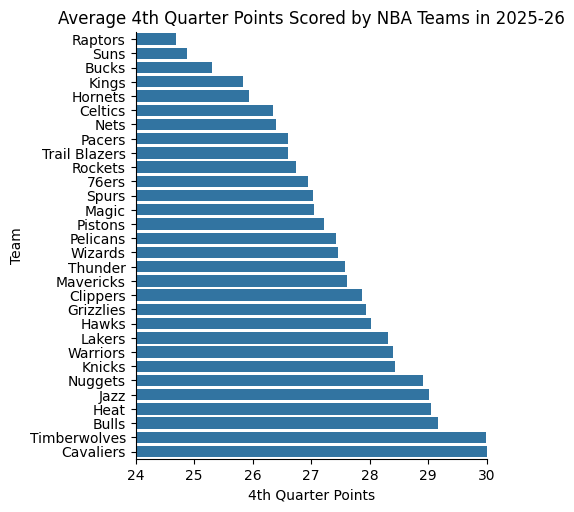

In [ ]:
Q4_pts = sns.catplot(data = team_quarters,
                     kind = 'bar',
                     x = 'ptsQ4',
                     y = 'teamName')

plt.xlim(24, 30)
plt.title('Average 4th Quarter Points Scored by NBA Teams in 2025-26');
plt.xlabel('4th Quarter Points');
plt.ylabel('Team');

The Cleveland Cavaliers score the most 4th quarter points in the NBA this year, but are closely followed by the Minnesota imberwolves.

### Q3: Come up with a another unique question. This question must use map() or apply()

Which teams have the highest winnings percentage in close games during 2026?

In [ ]:
# Your code here . . .
team_stats.columns

Index(['gameId', 'teamCity', 'teamName', 'gameType', 'season', 'astPct',
       'astRatio', 'astTo', 'defRating', 'drebPct', 'eDefRating', 'eNetRating',
       'eOffRating', 'ePace', 'efgPct', 'gameDate', 'home', 'matchup',
       'netRating', 'offRating', 'opponentTeamCity', 'opponentTeamId',
       'opponentTeamName', 'orebPct', 'pace', 'pacePer40', 'pie', 'poss',
       'rebPct', 'teamAbbreviation', 'tmTovPct', 'tsPct', 'wl'],
      dtype='object')

In [ ]:
current_team_stats = team_stats[team_stats['season'] == '2025-26']

In [ ]:
current_team_stats['win'] = current_team_stats['wl'].map({'W': 1, 'L':0})

/tmp/ipykernel_845/3165355756.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_team_stats['win'] = current_team_stats['wl'].map({'W': 1, 'L':0})


In [ ]:
close_games = current_team_stats[abs(current_team_stats['netRating']) <= 5]

In [ ]:
clutchtime = close_games.groupby('teamName')['win'].mean().sort_values(ascending=True).reset_index()

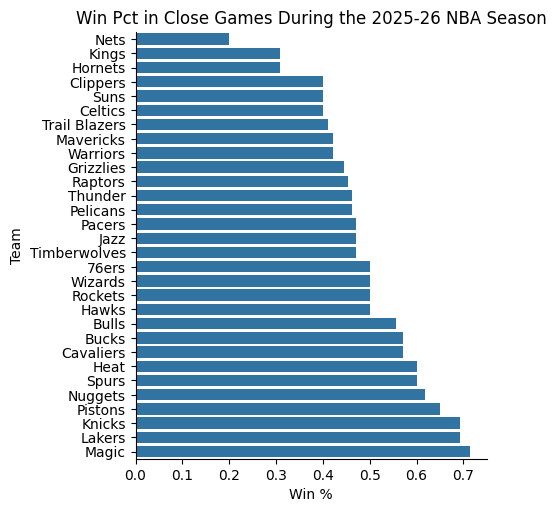

In [ ]:
clutch_pct = sns.catplot(data = clutchtime,
                     kind = 'bar',
                     x = 'win',
                     y = 'teamName')

plt.title('Win Pct in Close Games During the 2025-26 NBA Season');
plt.xlabel('Win %');
plt.ylabel('Team');

The Orlando Magic have the highest winnings percentage for the 2025-26 NBA season in close games.

### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [ ]:
import plotly.express as px

fig = px.bar(team_quarters,
             x='ptsQ4',
             y='teamName',
             orientation='h',
             title='Average 4th Quarter Points Scored by NBA Teams in 2025-26',
             labels={'ptsQ4': '4th Quarter Points', 'teamName': 'Team'})

fig.update_layout(yaxis={'categoryorder':'total ascending'})

fig.show()

Plots like this one which is generated by Plotly, can enhance communication by allowing audiance to engage directly with the data and see how much more competitive this season's 4th quarter is than with catplot. It can also make easier to compare specific teams by scanning the sorted bars. This engagement makes audiance want to stick around more and check out statistics by hovering over the graph. We want to communicate to audiance how competitive NBA has become and teams have improved and became especially competitive in 4th quarter, which is by many considered the most important one. With plotly graph, like I mentioned earlier people can check numbers and see how close these teams truly are and what kind of difference there is between top teams and those ranked lower.

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores?select=TeamStatisticsAdvanced.csv

NBA Database (1947 - Present) is the dataset we plan to use in addition to our current database. It is a NBA dataset and provides team and player box score data across NBA history. We belive it is a good addition to our dataset as it has certain statistics that our current dataset does not have.

### To make current dataset more complete we will include the following:

1. Game context data
    *   So Game results (win/loss) from years that are not present in our current database
    *   Home vs away indicator
    *   Opponents strength, so win percentage, their player points percentage, etc.

2. player Level Data
    *   Individual player stats (from PlayerStatistics.csv)
    *   Statistics like minutes played, usage rate or injuries can also be useful.

    These statistics are important because team's success is driven by player contribution and their statistics, which we can use for modeling or plots.

3. Schedule & Rest Data
    *   Back-to-back Games
    *   Days of Rest
    *   Travel distance

    These statistics are extremely important especially for modeling as fatigue strongly impacts performance of the player individually but is also linked to teams performance.


4. External Metrics (like elo rankings or team rankings, bettings odds or coachign and roster changes)

### We need to combine the datasets to make it easier to manage and use.

Pseudocode for combining the datasets would look something like this:

team_stats = read_csv("TeamStatisticsAdvanced.csv")

player_stats = read_csv("PlayerStatistics.csv")

games = read_csv("Games.csv")

team_games = merge(team_stats, games, on="GameID")

player_summary = player_stats.groupby(["GameID", "TeamID"]).sum()

full_data = merge(team_games, player_summary, on=["GameID", "TeamID"])

### Combined dataset may be too detialed for our needs so we will need to do some reshaping and cleaning

we would use following techniques:

1. We would aggregate to season level because:
    *   It would reduce noise from individual games
    *   Make it easier to compare teams across seasons
    *   Lastly, it would help identify long-term trends like team that scored most in 4th quarter.

    Pseudocode of what aggregation would look like:

    season_data = full_data.groupby(["Season", "TeamID"]).mean()

2. We would convert from wide to long format because:
    *   It would make visualization easier (especially when using tools like seaborn)
    *   Allow us to compare multiple metrics in a single plot
    *   Lastly, it would make the dataset more flexible especially for analysis.

    Pseudocode of what converting from wide to long format would look like:

    long_data = melt(full_data,

                 id_vars=["GameID", "TeamID"],
                 value_vars=["OffRating", "DefRating", "Pace"],
                 var_name="Metric",
                 value_name="Value"
      

3. We would create new variables because:
    *   Some useful insights are not in the database directly so we have to create them (like average points)
    *   It helps us simplify analysis and modeling.
    *   Lastly, it allows us to directly measure performance outcomes.  

    Pseudocode of what creating new variables would look like:

    full_data["PointDiff"] = full_data["Points"] - full_data["OpponentPoints"]

    full_data["Win"] = full_data["PointDiff"] > 0

### Visualization

We would use dataset for visualization. Right now we can only outline what potential visualization may look like.

1. Line Chart - Team Performance Over Time
    *   X-axis: Season
    * Y-axis: Offensive Rating
    * Each line = a team

2. Scatter Plot - Performance vs Winning
    * X-axis: Offensive Rating
    * Y-axis: Win Percentage

Overall we will definetly use plots but since we are still early in the project we don't know what kind of plots we will use.

### Conclusion
    
Overall, addings extra stuff to our dataset like game context, player stats or scheduling data like day of rest or back to back games would make our analysis much stronger. We would combine everything using shared IDs like GameID and TeamID, reshape the data and make it cleaner so we can use it easier to analyze and then potentially use it for visualization to better understand patterns and relationships inside the dataset.


